In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.axes import Axes
import seaborn as sns

In [3]:
df = pd.read_csv("../PRJNA723952.SraRunTable.csv")
df.shape

(1109, 34)

In [4]:
# count how many samples are from each genotype
df['genotype'].value_counts()

genotype
Col-0 x asy1Col-0/asy1Ler-1          224
asy1T142V-Col-0/asy1Ler-1 x Col-0    218
Col-0 x asy1T142V-Col-0/asy1Ler-1    216
asy1Col-0/asy1Ler-1 x Col-0          211
Col-0 x Col-0/Ler-1                  120
Col-0/Ler-1 x Col-0                  120
Name: count, dtype: int64

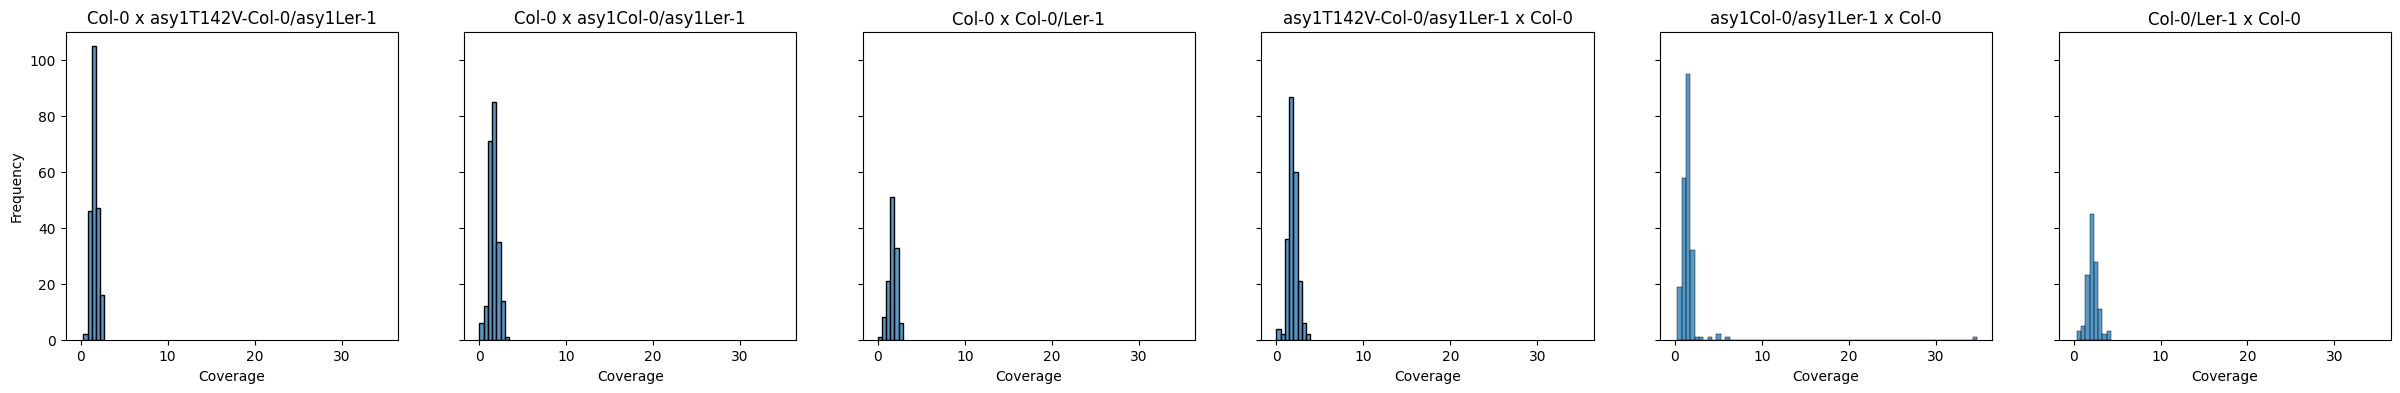

In [5]:
# for each genotype plot, plot the coverage in a subplot

genotypes = df['genotype'].unique()
df['coverage'] = df['Bases'] / 133_917_231
fig, axes = plt.subplots(nrows=1, ncols=len(genotypes), figsize=(5 * len(genotypes), 4), sharex=True, sharey=True)
for i, genotype in enumerate(genotypes):
    ax: Axes = axes[i]
    subset = df[df['genotype'] == genotype]
    sns.histplot(data=subset, x='coverage', ax=ax, binwidth=0.5)
    ax.set_title(f'{genotype}')
    ax.set_xlabel('Coverage')
    ax.set_ylabel('Frequency')

Filtered 94 samples out of 1109 total samples


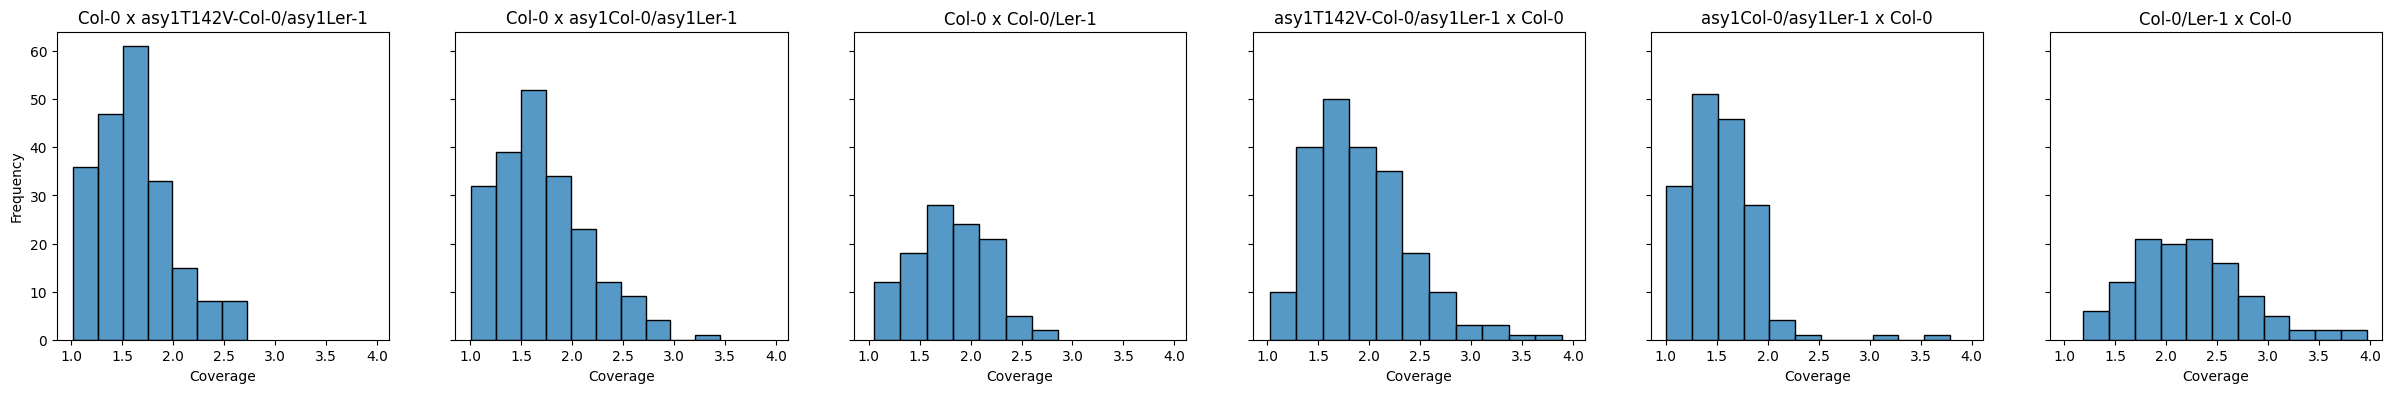

In [15]:
# filter coverage to be between 1 and 4

df_filtered = df[(df['coverage'] >= 1) & (df['coverage'] <= 4)]

print(f'Filtered {len(df) - len(df_filtered)} samples out of {len(df)} total samples')

# plot the filtered coverage
fig, axes = plt.subplots(nrows=1, ncols=len(genotypes), figsize=(5 * len(genotypes), 4), sharex=True, sharey=True)
for i, genotype in enumerate(genotypes):
    ax: Axes = axes[i]
    subset = df_filtered[df_filtered['genotype'] == genotype]
    sns.histplot(data=subset, x='coverage', ax=ax, binwidth=0.25)
    ax.set_title(f'{genotype}')
    ax.set_xlabel('Coverage')
    ax.set_ylabel('Frequency')
